# HLS S30 ETrF regressiya — qadam-baqadam (xarita + grafik)

Ko'ramiz:
1. L30 anchordan **ETrF = ET24/ETref**
2. Eng yaqin **HLS S30** tasviri va indekslari
3. **Regressiya** (ETrF ~ S30 NDVI) — scatter grafik + tenglama
4. Tenglama qo'llanib **bashorat ETrF** (boshqa S30 kunlariga ham)
5. 2 anchor → **vaqt bo'yicha interpolyatsiya**
6. ET_daily = ETrF × ETref → **oylik ET**

Barcha mantiq `hls_s30_etrf` modulidan chaqiriladi.

In [1]:
# Cell 1 — Setup
import ee, geemap
import numpy as np, matplotlib.pyplot as plt
ee.Initialize(project='carbon-science-461016-q2')
from sebal_gee_v4 import ee_utils; ee_utils.install_getinfo_retry()
from sebal_gee_v4 import main as M
from sebal_gee_v4 import hls_s30_etrf as s30
from sebal_gee_v4 import viirs_downscaling as vds   # fit + samples helperlari
print('OK')

OK


In [2]:
# Cell 2 — Konfiguratsiya + TILE chegarasi
TILE  = 'T41SPD'
START, END = '2026-05-01', '2026-05-31'
MODEL = 'multi'        # 'ndvi' | 'ndvi2' | 'multi'
QA    = 'lenient'

roi = (ee.FeatureCollection('FAO/GAUL/2015/level1')
       .filter(ee.Filter.eq('ADM1_NAME', 'Kashkadarya')).geometry())
tile_geom = M.get_hls_tile_geometry(TILE, START, END)
tile_roi  = roi.intersection(tile_geom, ee.ErrorMargin(30))

Map = geemap.Map()
Map.centerObject(tile_roi, 9)
Map.addLayer(tile_roi, {'color': 'red'}, f'TILE {TILE}', True, 0.4)
Map

Map(center=[38.934817148321756, 64.6500130755285], controls=(WidgetControl(options=['position', 'transparent_b…

In [3]:
# Cell 3 — L30 SEBAL anchorlar (process_tile)
scenes, info = M.process_tile(tile_roi, START, END, 'pysebal', 'HLS', 70, TILE)
anchors = [{'image': ee.Image(s), 'date': info['dates'][i]}
           for i, s in enumerate(scenes)]
print('L30 anchorlar:', info['dates'])
a0 = anchors[0]

      ✅ 2026-05-06: ekin bulut 0.3%
      ⚠️ 2026-05-07: ekin bulut 100.0% > 30% → skip
      ⚠️ 2026-05-14: ekin bulut 100.0% > 30% → skip
      ✅ 2026-05-15: ekin bulut 0.3%
      ✅ 2026-05-22: ekin bulut 0.0%
      ✅ 2026-05-30: ekin bulut 0.0%
  [T41SPD] Filtrlangan: Path=None Row=None → 4 tasvir
  [T41SPD] Tasvirlar: 4 | ['2026-05-06', '2026-05-15', '2026-05-22', '2026-05-30']
  [T41SPD] Sahna 1/4...
  🌾 Anchor cropland mask pixel count: {'SLOPE': 75737}
  [T41SPD] Sahna 2/4...
  🌾 Anchor cropland mask pixel count: {'SLOPE': 75737}
  [T41SPD] Sahna 3/4...
  🌾 Anchor cropland mask pixel count: {'SLOPE': 75737}
  [T41SPD] Sahna 4/4...
  🌾 Anchor cropland mask pixel count: {'SLOPE': 75737}
L30 anchorlar: ['2026-05-06', '2026-05-15', '2026-05-22', '2026-05-30']


In [4]:
# Cell 4 — ETrF = ET24 / ETREF_24 (bitta anchor kuni)
etrf0 = s30.compute_etrf(a0['image'])   # 'target' band
etrf_vis = {'min': 0, 'max': 1.2, 'palette': ['brown', 'yellow', 'green', 'blue']}
Map.addLayer(etrf0.clip(tile_roi), etrf_vis, f"ETrF (L30 {a0['date']})")
print('ETrF tayyor —', a0['date'])
Map

ETrF tayyor — 2026-05-06


Map(bottom=50424.0, center=[38.934817148321756, 64.6500130755285], controls=(WidgetControl(options=['position'…

In [5]:
# Cell 5 — HLS S30 kolleksiyasi + anchorga ENG YAQIN S30
s30_col = s30.get_s30_collection(tile_roi, START, END, 70, TILE)
s30_dates = s30.s30_available_dates(s30_col)
print('S30 clear kunlar:', s30_dates)

cd = s30._closest_date(a0['date'], s30_dates)
print(f"{a0['date']} ga eng yaqin S30: {cd}")
idx0 = s30.s30_day_indices(s30_col, cd, QA)
ndvi_vis = {'min': 0, 'max': 0.8, 'palette': ['white', 'khaki', 'green']}
Map.addLayer(idx0.select('NDVI').clip(tile_roi), ndvi_vis, f'S30 NDVI {cd}')
Map

      ✅ 2026-05-06: ekin bulut 0.2%
      ✅ 2026-05-11: ekin bulut 0.0%
      ✅ 2026-05-13: ekin bulut 0.0%
      ✅ 2026-05-16: ekin bulut 0.0%
      ✅ 2026-05-26: ekin bulut 0.1%
      ✅ 2026-05-31: ekin bulut 0.0%
S30 clear kunlar: ['2026-05-06', '2026-05-11', '2026-05-13', '2026-05-16', '2026-05-26', '2026-05-31']
2026-05-06 ga eng yaqin S30: 2026-05-06


Map(bottom=50424.0, center=[38.934817148321756, 64.6500130755285], controls=(WidgetControl(options=['position'…

Tenglama: {'a': 0.4885, 'b_NDVI': 3.8743, 'c_EVI2': -8.6605, 'd_NDWI': 1.4678}
R2=0.620  RMSE=0.110  N=815


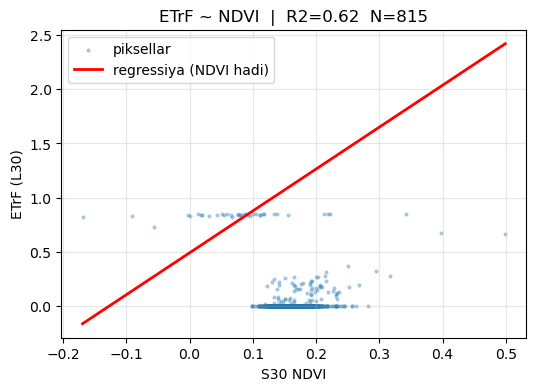

In [6]:
# Cell 6 — REGRESSIYA: ETrF ~ S30 indeks (scatter + tenglama)
# Faqat ETrF MAVJUD piksellardan namuna (dropNulls)
stack = idx0.addBands(etrf0)   # NDVI, EVI2, NDWI, target
fc = stack.sample(region=tile_roi, scale=30, numPixels=2000, seed=42,
                  dropNulls=True, geometries=False, tileScale=8)
snp = vds.samples_to_numpy(fc)
reg = vds.fit_viirs_regression(snp, MODEL)
print('Tenglama:', {k: round(v, 4) for k, v in reg['coeffs'].items()})
print(f"R2={reg['R2']:.3f}  RMSE={reg['RMSE']:.3f}  N={reg['N']}")

# Scatter: NDVI vs ETrF + fit chizig'i
x, y = snp['NDVI'], snp['target']
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=4, alpha=0.3, label='piksellar')
xs = np.linspace(x.min(), x.max(), 50)
c = reg['coeffs']
ys = c['a'] + c['b_NDVI'] * xs   # NDVI hadi (asosiy bog'liqlik)
plt.plot(xs, ys, 'r-', lw=2, label='regressiya (NDVI hadi)')
plt.xlabel('S30 NDVI'); plt.ylabel('ETrF (L30)')
plt.title(f"ETrF ~ NDVI  |  R2={reg['R2']:.2f}  N={reg['N']}")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [7]:
# Cell 7 — Tenglamani qo'llash: bashorat ETrF vs HAQIQIY ETrF
pred_etrf = s30.predict_etrf(idx0, reg, MODEL)
Map.addLayer(pred_etrf.clip(tile_roi), etrf_vis, f'Bashorat ETrF (S30 {cd})')
Map.addLayer(etrf0.clip(tile_roi), etrf_vis, f'HAQIQIY ETrF (L30 {a0["date"]})', False)
# Farq
diff = pred_etrf.rename('p').subtract(etrf0.rename('p'))
Map.addLayer(diff.clip(tile_roi), {'min': -0.3, 'max': 0.3,
             'palette': ['blue', 'white', 'red']}, 'Farq (bashorat - haqiqiy)', False)
Map

Map(bottom=50332.0, center=[39.13006024213511, 66.01409912109376], controls=(WidgetControl(options=['position'…

In [8]:
# Cell 8 — Tenglama BOSHQA S30 kuniga ham qo'llanadi
other = s30_dates[len(s30_dates) // 2]   # o'rtadagi S30 kun
idx_o = s30.s30_day_indices(s30_col, other, QA)
etrf_o = s30.predict_etrf(idx_o, reg, MODEL)
Map.addLayer(etrf_o.clip(tile_roi), etrf_vis, f'ETrF bashorat (S30 {other})')
print('Boshqa S30 kun:', other)
Map

Boshqa S30 kun: 2026-05-16


Map(bottom=50332.0, center=[39.13006024213511, 66.01409912109376], controls=(WidgetControl(options=['position'…

In [9]:
# Cell 9 — INTERPOLYATSIYA: 2 anchor tenglamasi vaqt bo'yicha blend
# Har anchor uchun tenglama, keyin between-day uchun blend
regs = []
for a in anchors:
    r, c_ = s30.fit_etrf_regression(a['image'], s30_col, a['date'],
                                    s30_dates, tile_roi, MODEL, QA)
    if 'coeffs' in r:
        regs.append({'date': a['date'], 'ord': s30._date_ord(a['date']), 'reg': r})
        print(f"  {a['date']}: R2={r['R2']:.3f}")
regs.sort(key=lambda z: z['ord'])

# Ikki anchor orasidagi S30 kun uchun blend
bday = s30_dates[1] if len(s30_dates) > 1 else s30_dates[0]
do = s30._date_ord(bday)
before = [r for r in regs if r['ord'] <= do][-1]
after = [r for r in regs if r['ord'] >= do][0]
idx_b = s30.s30_day_indices(s30_col, bday, QA)
if before['date'] != after['date']:
    pa = s30.predict_etrf(idx_b, before['reg'], MODEL)
    pb = s30.predict_etrf(idx_b, after['reg'], MODEL)
    alpha = (do - before['ord']) / (after['ord'] - before['ord'])
    blended = pa.multiply(1 - alpha).add(pb.multiply(alpha))
    print(f"{bday}: {before['date']} va {after['date']} orasida, alpha={alpha:.2f}")
else:
    blended = s30.predict_etrf(idx_b, before['reg'], MODEL)
Map.addLayer(blended.clip(tile_roi), etrf_vis, f'Blend ETrF {bday}')
Map

  2026-05-06: R2=0.608
  2026-05-15: R2=0.398
  2026-05-22: R2=0.128
  2026-05-30: R2=0.364
2026-05-11: 2026-05-06 va 2026-05-15 orasida, alpha=0.56


Map(bottom=50332.0, center=[39.13006024213511, 66.01409912109376], controls=(WidgetControl(options=['position'…

In [10]:
# Cell 10 — TILE uchun OYLIK ET (to'liq orkestrator)
monthly = s30.build_tile_monthly_etrf_s30(
    scenes, info, tile_roi, START, END, MODEL, QA, 'linear', 70, TILE)
etm_vis = {'min': 0, 'max': 180,
           'palette': ['white', 'yellow', 'green', 'blue', 'navy']}
Map.addLayer(monthly.clip(tile_roi), etm_vis, 'S30 OYLIK ET (mm/oy)')
Map

      ✅ 2026-05-06: ekin bulut 0.2%
      ✅ 2026-05-11: ekin bulut 0.0%
      ✅ 2026-05-13: ekin bulut 0.0%
      ✅ 2026-05-16: ekin bulut 0.0%
      ✅ 2026-05-26: ekin bulut 0.1%
      ✅ 2026-05-31: ekin bulut 0.0%
    S30 clear kunlar: 6
    ETrF~S30 [2026-05-06→S30 2026-05-06] multi: R2=0.608 N=1224
    ETrF~S30 [2026-05-15→S30 2026-05-16] multi: R2=0.398 N=2490
    ETrF~S30 [2026-05-22→S30 2026-05-26] multi: R2=0.128 N=1813
    ETrF~S30 [2026-05-30→S30 2026-05-31] multi: R2=0.364 N=1587


Map(bottom=50332.0, center=[39.13006024213511, 66.01409912109376], controls=(WidgetControl(options=['position'…